In [ ]:
import jax.numpy as jnp
import matplotlib.pyplot as plt
import jeanspy.model_numpyro as model

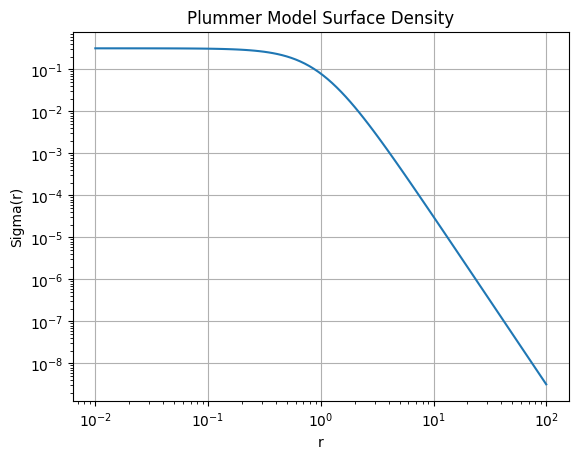

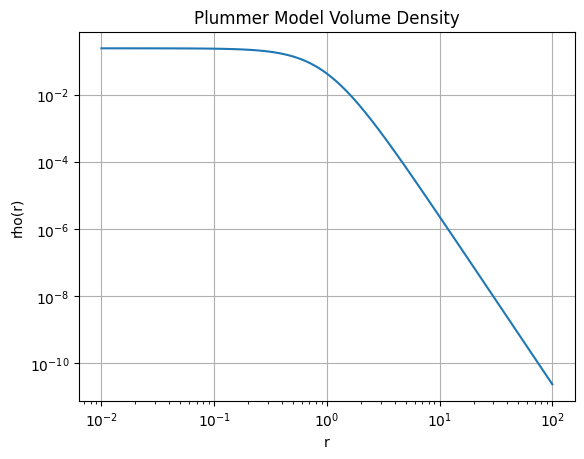

In [2]:
# Stellar models
mdl = model.PlummerModel()
r = jnp.logspace(-2, 2, 100)
sigma = mdl.density_2d(r,re_pc=1.0)
plt.plot(r, sigma)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("r")
plt.ylabel("Sigma(r)")
plt.title("Plummer Model Surface Density")
plt.grid()
plt.show()
rho = mdl.density_3d(r,re_pc=1.0)
plt.plot(r, rho)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("r")
plt.ylabel("rho(r)")
plt.title("Plummer Model Volume Density")
plt.grid()
plt.show()

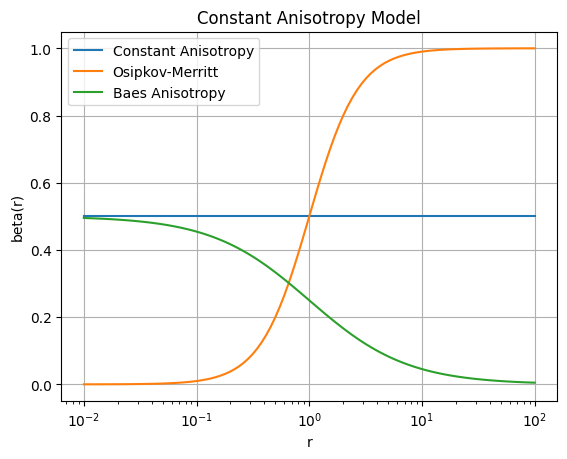

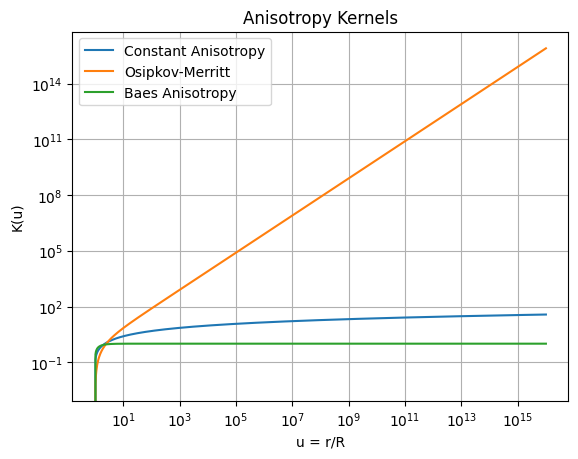

beta_ani=-10.0, k_0=[0.         1.7964352  1.6243118  ... 0.04761904 0.04761904 0.04761904]
beta_ani=-9.9, k_0=[0.         1.7878604  1.6219488  ... 0.04807693 0.04807693 0.04807693]
beta_ani=-9.8, k_0=[0.         1.7791862  1.6194888  ... 0.04854369 0.04854369 0.04854369]
beta_ani=-9.7, k_0=[0.         1.7704122  1.6169295  ... 0.04901958 0.04901958 0.04901958]
beta_ani=-9.6, k_0=[0.         1.7615373  1.6142689  ... 0.04950494 0.04950494 0.04950494]
beta_ani=-9.5, k_0=[0.         1.7525605  1.6115046  ... 0.05000001 0.05000001 0.05000001]
beta_ani=-9.4, k_0=[0.         1.7434808  1.6086347  ... 0.05050504 0.05050504 0.05050504]
beta_ani=-9.3, k_0=[0.         1.7342975  1.6056569  ... 0.05102038 0.05102038 0.05102038]
beta_ani=-9.2, k_0=[0.         1.7250094  1.602569   ... 0.05154645 0.05154645 0.05154645]
beta_ani=-9.1, k_0=[0.         1.7156156  1.5993686  ... 0.05208331 0.05208331 0.05208331]
beta_ani=-9.0, k_0=[0.         1.7061152  1.5960535  ... 0.05263162 0.05263162 0.05263162

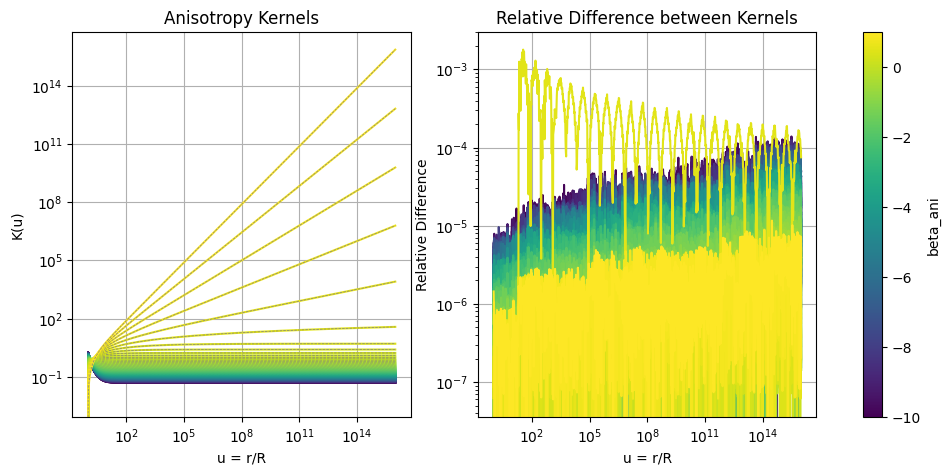

In [ ]:
import jax.numpy as jnp
import matplotlib.pyplot as plt
import jeanspy.model_numpyro as model
# anisotropy model
mdl_0 = model.ConstantAnisotropyModel()
mdl_1 = model.OsipkovMerrittModel()
mdl_2 = model.BaesAnisotropyModel()
params_0 = {"beta_ani": 0.5}
params_1 = {"r_a": 1.0}
params_2 = {"beta_0": 0.5, "r_a": 1.0, "beta_inf": 0.0, "eta": 1.0}
r = jnp.logspace(-2, 2, 100)
beta_0 = mdl_0.beta(r, params=params_0)
plt.plot(r, beta_0, label="Constant Anisotropy")
beta_1 = mdl_1.beta(r, params=params_1)
plt.plot(r, beta_1, label="Osipkov-Merritt")
beta_2 = mdl_2.beta(r, params=params_2)
plt.plot(r, beta_2, label="Baes Anisotropy")
plt.legend()
plt.xscale("log")
plt.xlabel("r")
plt.ylabel("beta(r)")
plt.title("Constant Anisotropy Model")
plt.grid()
plt.show()

# plot kernels
u = jnp.logspace(0, 16, 1024)
R = jnp.array(100)
k_0 = mdl_0.kernel(u, R, params=params_0, backend="scipy")
k_1 = mdl_1.kernel(u, R, params=params_1)
k_2 = mdl_2.kernel(u, R, params=params_2)
plt.plot(u, k_0, label="Constant Anisotropy")
plt.plot(u, k_1, label="Osipkov-Merritt")
plt.plot(u, k_2, label="Baes Anisotropy")
plt.legend()
plt.xscale("log")
plt.yscale("log")
plt.xlabel("u = r/R")
plt.ylabel("K(u)")
plt.title("Anisotropy Kernels")
plt.grid()
plt.show()

# check the consistency of the kernels
fig,axes = plt.subplots(1,2,figsize=(12,5))
for i,beta_ani in enumerate(jnp.arange(-10,1.1,0.1)):
    color = plt.cm.viridis(i / 110)
    params_0 = {"beta_ani": beta_ani}
    params_2 = {"beta_0": beta_ani, "r_a": 1.0, "beta_inf": beta_ani, "eta": 1.0}
    k_0 = mdl_0.kernel(u, R, params=params_0, backend="scipy")
    print(f"beta_ani={beta_ani:.1f}, k_0={k_0}")
    k_2 = mdl_2.kernel(u, R, params=params_2)
    # axes[0] is for the kernels, axes[1] is for the relative difference
    axes[0].plot(u, k_0, label=f"beta={beta_ani:.1f}", color=color)
    axes[0].plot(u, k_2, color="gray", linestyle="--", linewidth=0.5)
    rel_diff = jnp.abs(k_0 - k_2) / jnp.abs(k_0)
    axes[1].plot(u, rel_diff, label=f"beta={beta_ani:.1f}", color=color)
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlabel("u = r/R")
axes[0].set_ylabel("K(u)")
axes[0].set_title("Anisotropy Kernels")
axes[0].grid()
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_xlabel("u = r/R")
axes[1].set_ylabel("Relative Difference")
axes[1].set_title("Relative Difference between Kernels")
axes[1].grid()
# axes[0].legend()
# axes[1].legend()
# add colorbar for the beta_ani values
sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis, norm=plt.Normalize(vmin=-10, vmax=1))
cbar = fig.colorbar(sm, ax=axes, orientation="vertical", label="beta_ani")
plt.show()


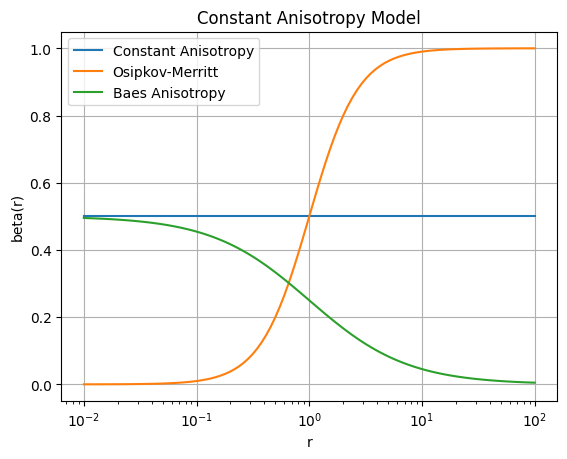

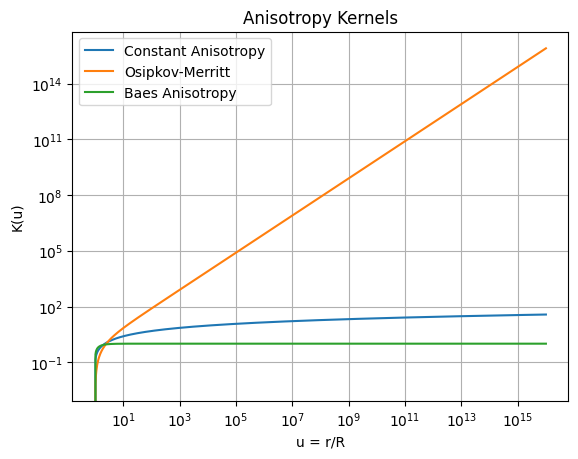

beta_ani=-10.0, k_0=[0.         1.7964349  1.6243122  ... 0.04761624 0.04761624 0.04761624]
beta_ani=-9.9, k_0=[0.         1.7878599  1.6219492  ... 0.04810244 0.04810244 0.04810244]
beta_ani=-9.8, k_0=[0.        1.779186  1.6194891 ... 0.0485729 0.0485729 0.0485729]
beta_ani=-9.7, k_0=[0.         1.7704118  1.6169299  ... 0.04898554 0.04898554 0.04898554]
beta_ani=-9.6, k_0=[0.         1.7615367  1.6142691  ... 0.04948044 0.04948044 0.04948044]
beta_ani=-9.5, k_0=[0.         1.7525601  1.6115052  ... 0.05002105 0.05002105 0.05002105]
beta_ani=-9.4, k_0=[0.         1.7434804  1.6086347  ... 0.05053043 0.05053043 0.05053043]
beta_ani=-9.3, k_0=[0.         1.734297   1.6056572  ... 0.05100548 0.05100548 0.05100548]
beta_ani=-9.2, k_0=[0.         1.725009   1.6025691  ... 0.05151135 0.05151135 0.05151135]
beta_ani=-9.1, k_0=[0.        1.7156152 1.5993688 ... 0.0520556 0.0520556 0.0520556]
beta_ani=-9.0, k_0=[0.         1.7061148  1.5960537  ... 0.05259711 0.05259711 0.05259711]
beta_ani=-

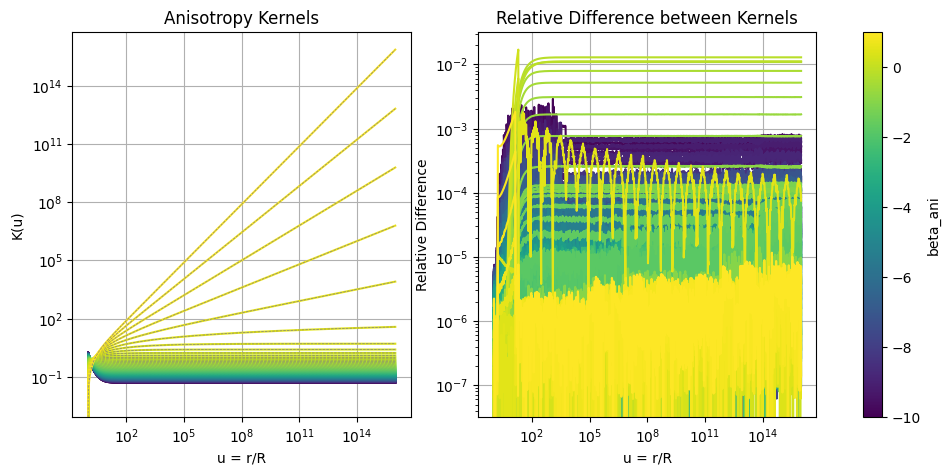

In [4]:
# anisotropy model
mdl_0 = model.ConstantAnisotropyModel()
mdl_1 = model.OsipkovMerrittModel()
mdl_2 = model.BaesAnisotropyModel()
params_0 = {"beta_ani": 0.5}
params_1 = {"r_a": 1.0}
params_2 = {"beta_0": 0.5, "r_a": 1.0, "beta_inf": 0.0, "eta": 1.0}
r = jnp.logspace(-2, 2, 100)
beta_0 = mdl_0.beta(r, params=params_0)
plt.plot(r, beta_0, label="Constant Anisotropy")
beta_1 = mdl_1.beta(r, params=params_1)
plt.plot(r, beta_1, label="Osipkov-Merritt")
beta_2 = mdl_2.beta(r, params=params_2)
plt.plot(r, beta_2, label="Baes Anisotropy")
plt.legend()
plt.xscale("log")
plt.xlabel("r")
plt.ylabel("beta(r)")
plt.title("Constant Anisotropy Model")
plt.grid()
plt.show()

# plot kernels
u = jnp.logspace(0, 16, 1024)
R = jnp.array(100)
k_0 = mdl_0.kernel(u, R, params=params_0)
k_1 = mdl_1.kernel(u, R, params=params_1)
k_2 = mdl_2.kernel(u, R, params=params_2)
plt.plot(u, k_0, label="Constant Anisotropy")
plt.plot(u, k_1, label="Osipkov-Merritt")
plt.plot(u, k_2, label="Baes Anisotropy")
plt.legend()
plt.xscale("log")
plt.yscale("log")
plt.xlabel("u = r/R")
plt.ylabel("K(u)")
plt.title("Anisotropy Kernels")
plt.grid()
plt.show()

# check the consistency of the kernels
fig,axes = plt.subplots(1,2,figsize=(12,5))
for i,beta_ani in enumerate(jnp.arange(-10,1.1,0.1)):
    color = plt.cm.viridis(i / 110)
    params_0 = {"beta_ani": beta_ani}
    params_2 = {"beta_0": beta_ani, "r_a": 1.0, "beta_inf": beta_ani, "eta": 1.0}
    k_0 = mdl_0.kernel(u, R, params=params_0)
    print(f"beta_ani={beta_ani:.1f}, k_0={k_0}")
    k_2 = mdl_2.kernel(u, R, params=params_2)
    # axes[0] is for the kernels, axes[1] is for the relative difference
    axes[0].plot(u, k_0, label=f"beta={beta_ani:.1f}", color=color)
    axes[0].plot(u, k_2, color="gray", linestyle="--", linewidth=0.5)
    rel_diff = jnp.abs(k_0 - k_2) / jnp.abs(k_0)
    axes[1].plot(u, rel_diff, label=f"beta={beta_ani:.1f}", color=color)
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlabel("u = r/R")
axes[0].set_ylabel("K(u)")
axes[0].set_title("Anisotropy Kernels")
axes[0].grid()
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_xlabel("u = r/R")
axes[1].set_ylabel("Relative Difference")
axes[1].set_title("Relative Difference between Kernels")
axes[1].grid()
# axes[0].legend()
# axes[1].legend()
# add colorbar for the beta_ani values
sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis, norm=plt.Normalize(vmin=-10, vmax=1))
cbar = fig.colorbar(sm, ax=axes, orientation="vertical", label="beta_ani")
plt.show()



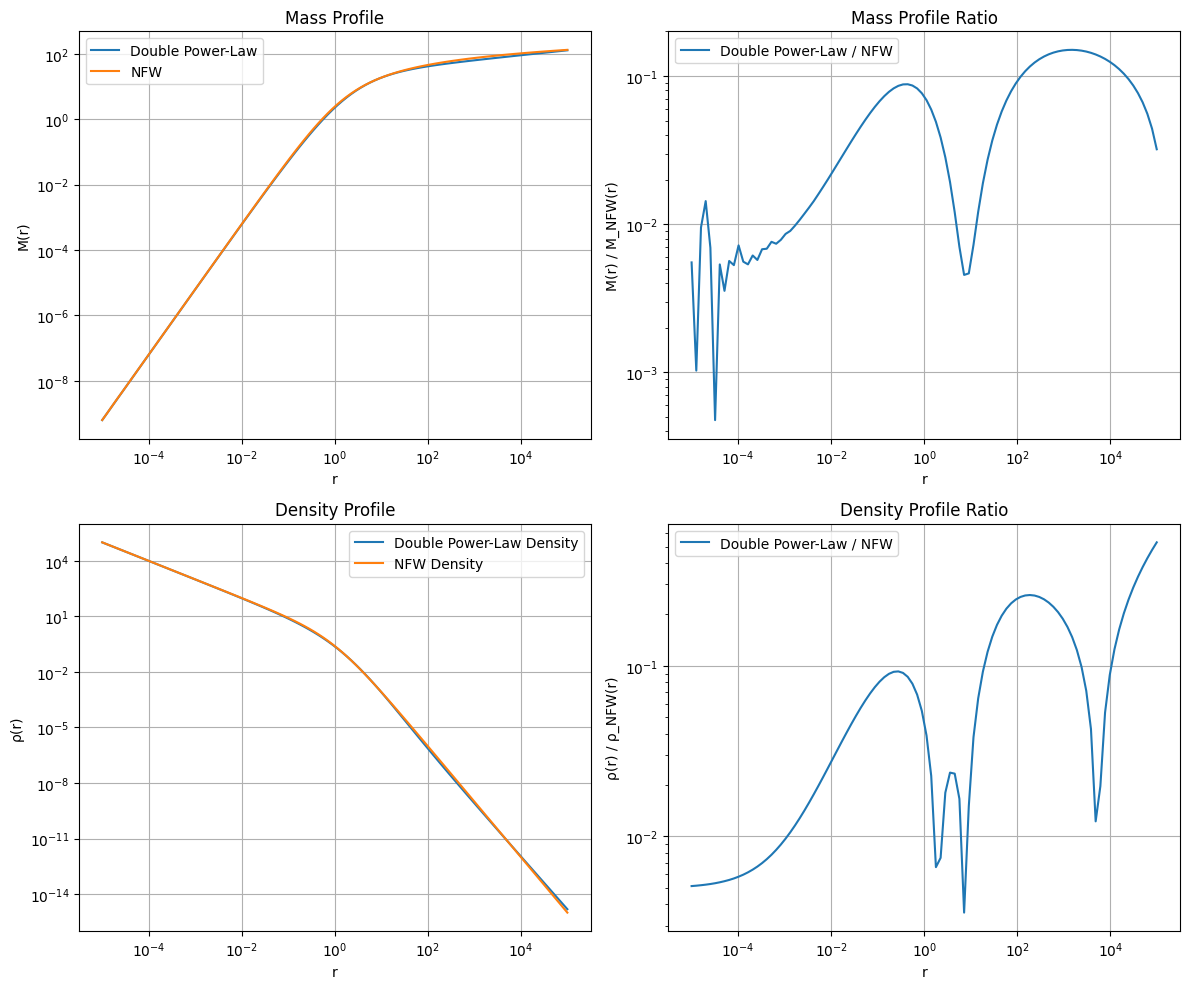

In [44]:
# how about mass profile instead of density profile?
import os 
os.environ.setdefault("XLA_PYTHON_CLIENT_PREALLOCATE", "false")
from jax import grad, vmap
import jax.numpy as jnp
import matplotlib.pyplot as plt
from jeanspy.model_numpyro import NFWModel

def mass_profile(r, M, r_s, pow_in, pow_out, smoothness):
    # # double power-law mass profile
    # x = r / r_s
    # return M * x**pow_in * (1 + x**(1/smoothness))**(smoothness*(pow_out-pow_in))
    return jnp.exp(log_mass_profile(r, M, r_s, pow_in, pow_out, smoothness))

def log_mass_profile(r, M, r_s, pow_in, pow_out, smoothness):
    # double power-law mass profile
    x = r / r_s
    return jnp.log(M) + pow_in * jnp.log(x) + smoothness*(pow_out-pow_in) * jnp.log1p(x**(1/smoothness))

# NOTE: NFW profile behaves as r^-1 for very small r.
# which means that the mass profile behaves as r^2 for very small r:
# M(r) = \int 4\pi r^2 \rho(r) dr = \int 4\pi r^2 (r/rs)^-1 dr = \int 4\pi rs r dr = 2\pi rs r^2

dmdr = grad(mass_profile, argnums=0)
dmdr_vmap = vmap(dmdr, in_axes=(0, None, None, None, None, None))

def density_profile(r, M, r_s, pow_in, pow_out, smoothness):
    m = mass_profile(r, M, r_s, pow_in, pow_out, smoothness)
    if isinstance(r, float):
        _dm_dr = dmdr(r, M, r_s, pow_in, pow_out, smoothness)
    elif isinstance(r, jnp.ndarray):
        _dm_dr = dmdr_vmap(r, M, r_s, pow_in, pow_out, smoothness)
    return _dm_dr / (4 * jnp.pi * r**2)

r_s = 2.01
params = {"M": 4*jnp.pi*r_s, "r_s": r_s, "pow_in": 2.0, "pow_out": 0.15, "smoothness": 1.23}
params_nfw = {"rs_pc": 1.0, "rhos_Msunpc3": 1.0, "r_t_pc": 1e10}
_x = jnp.logspace(-5, 5, 100)
_m = mass_profile(_x, **params) 
# _m /= mass_profile(params["r_s"], **params)
_m_nfw = NFWModel().enclosed_mass(_x, params=params_nfw) 
# _m_nfw /= NFWModel().enclosed_mass(jnp.array(params_nfw["rs_pc"]), params=params_nfw)
fig,axes = plt.subplots(2,2,figsize=(12,10))
axes[0,0].loglog(_x, _m, label="Double Power-Law")
axes[0,0].loglog(_x, _m_nfw, label="NFW")
axes[0,0].set_xlabel("r")
axes[0,0].set_ylabel("M(r)")
axes[0,0].set_title("Mass Profile")
axes[0,0].legend()
axes[0,0].grid()
axes[0,1].loglog(_x, jnp.abs(_m-_m_nfw)/_m_nfw, label="Double Power-Law / NFW")
axes[0,1].set_xlabel("r")
axes[0,1].set_ylabel("M(r) / M_NFW(r)")
axes[0,1].set_title("Mass Profile Ratio")
axes[0,1].legend()
axes[0,1].grid()
rho = density_profile(_x, **params)
# rho /= density_profile(params["r_s"], **params)
rho_nfw = NFWModel().mass_density_3d(_x, params=params_nfw)
# rho_nfw /= NFWModel().mass_density_3d(jnp.array(params_nfw["rs_pc"]), params=params_nfw)
axes[1,0].loglog(_x, rho, label="Double Power-Law Density")
axes[1,0].loglog(_x, rho_nfw, label="NFW Density")
axes[1,0].set_xlabel("r")
axes[1,0].set_ylabel("ρ(r)")
axes[1,0].set_title("Density Profile")
axes[1,0].legend()
axes[1,0].grid()
axes[1,1].loglog(_x, jnp.abs(rho-rho_nfw)/rho_nfw, label="Double Power-Law / NFW")
axes[1,1].set_xlabel("r")
axes[1,1].set_ylabel("ρ(r) / ρ_NFW(r)")
axes[1,1].set_title("Density Profile Ratio")
axes[1,1].legend()
axes[1,1].grid()
fig.tight_layout()
plt.show()